<a href="https://colab.research.google.com/github/emurlu024/capstone/blob/main/ODE_Integrator_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Codeing with new method (integrator)

- Symplectic method ODE: **Yoshida 4th/WH**

**Changes to be made from Newton Raphson...**

Extra parameters needed for symplectic
- Explicit epoch (NEO)
- Explicit epoch (Earth)
  
  *Positionals NEO (adjust to master epoch)*
- r_0 (x,y,z)
- v_0 (v_x, v_y, v_z)
- Δv
  
  *Positionals Earth (constant)*
- r_0 (x,y,z)
- v_0 (v_x, v_y, v_z)
- Δv

Plan:
- Have a master epoch (based on Earth) and alter the specific NEO parameters around that Epoch
   
      Therefore, we will have a constant across all simulations
- We will calculate the positionals for NEO --> through

**Simulation 1: Currently Hazardous**
    
    NEO: 2024 YR4

Parameters: (source - NASA & JPL SBDB) --> Same as NRM
- Eccentricity --> **ecc** (e): 0.66426900
- Semi-major axis --> **sm_axis** (a): 2.54000858 AU
- Inclination --> **inc** (i): 3.45326192°
- Longitude of ascending node --> **asc_node** (Ω): 271.41230059°
- Perihelion --> **p_helion** (ω): 134.64151115°
- Mean anomaly --> **mean** (M₀): 39.7746°

New for integrator:
- Grand Epoch (Constant - Earth): 2025-05-05 (JD 2460800.5)
- NEO Epoch (respectively):

Updated Param: Coordinate system
- position --> **r_0** (r_0):
- velocity --> **v_0** (v_0):

Perturbations to NEO (code parameter - +velocity):
- +0.1% velocity
- +0.5% velocity

    Code for +0.1%

Code below:

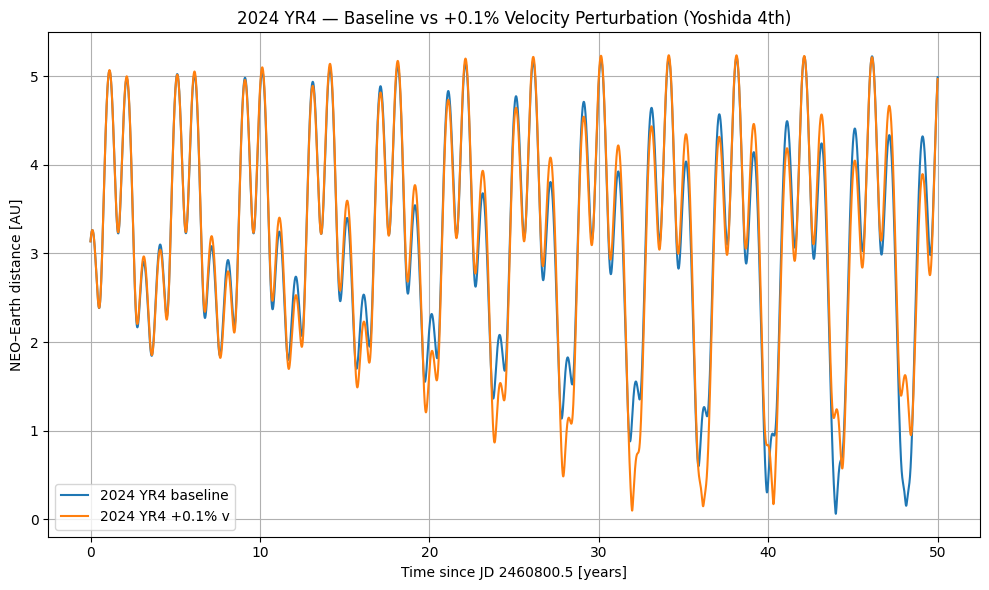


-------------------------MINIMUM DISTANCE REPORT--------------------------
2024 YR4 – Minimum Earth Distance (baseline): 8969168.35 km at year 43.99
2024 YR4 – Minimum Earth Distance (+0.1% v): 14350958.21 km at year 31.97
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 2024YR4_perturbed_0.1_AU.csv
Location : /content/2024YR4_perturbed_0.1_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2024 YR4 - +0.1% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#2024 YR4 orbital parameters
    #@ JD 2460800.5
ecc      = 0.66426900          #eccentricity (e)
sm_axis  = 2.54000858          #semi-major axis[AU] (a)
inc_deg  = 3.45326192          #inclination degrees (i) [deg]
asc_node_deg = 271.41230059    #ascending node degrees (Ω) [deg]
arg_peri_deg  = 134.64151115   #perhelion (ω) [deg]
mean_anom_epoch_deg = 39.7746  #mean anomaly at JD 2460800.5 (M) [deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 2024 YR4 at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.1% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.001   #+0.1% --> 0.001 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.1% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.1% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.001)  #+0.1% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="2024 YR4 baseline")
    plt.plot(t_years_arr, d_pert_AU, label="2024 YR4 +0.1% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("2024 YR4 — Baseline vs +0.1% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("2024 YR4 – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("2024 YR4 – Minimum Earth Distance (+0.1% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")






# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "2024YR4_perturbed_0.1_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)



    Code for +0.5%

Code below:

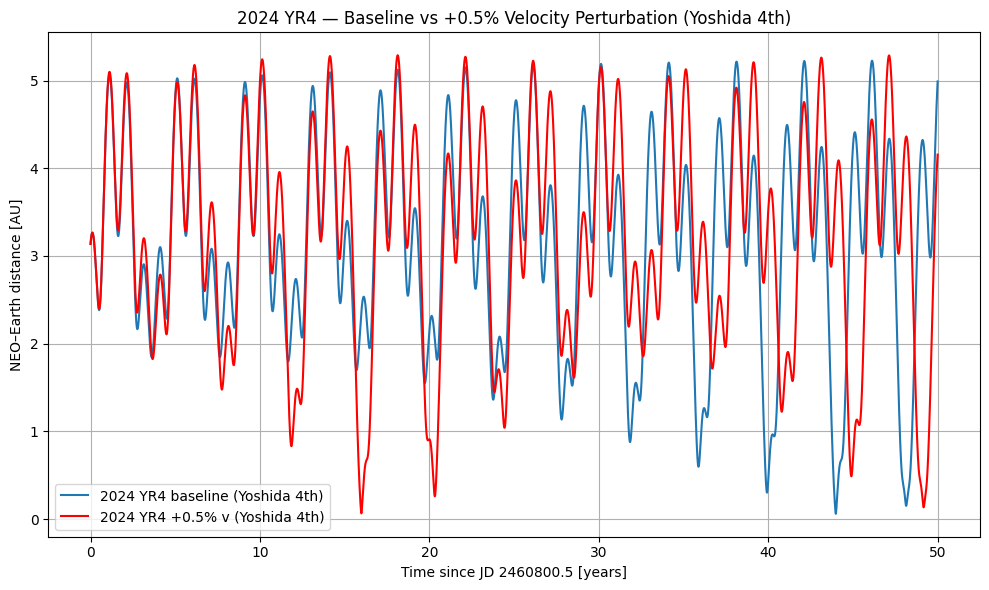


-------------------------MINIMUM DISTANCE REPORT--------------------------
2024 YR4 – Minimum Earth Distance (baseline): 8969168.35 km at year 43.99
2024 YR4 – Minimum Earth Distance (+0.5% v): 9635909.73 km at year 15.99
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 2024YR4_perturbed_0.5_AU.csv
Location : /content/2024YR4_perturbed_0.5_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2024 YR4 - +0.5% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#2024 YR4 orbital parameters (same as +0.1%)
    #@ JD 2460800.5
ecc      = 0.66426900          #eccentricity (e)
sm_axis  = 2.54000858          #semi-major axis[AU] (a)
inc_deg  = 3.45326192          #inclination degrees (i) [deg]
asc_node_deg = 271.41230059    #ascending node degrees (Ω) [deg]
arg_peri_deg  = 134.64151115   #perhelion (ω) [deg]
mean_anom_epoch_deg = 39.7746  #mean anomaly at JD 2460800.5 (M) [deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#------------------------------------------------------------------------------------
#solve Kepler's equation --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E
#------------------------------------------------------------------------------------

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 2024 YR4 at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.5% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.005   #+0.5% --> 0.001 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.1% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.5% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.005)  #+0.5% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="2024 YR4 baseline (Yoshida 4th)")
    plt.plot(t_years_arr, d_pert_AU, color = 'red', label="2024 YR4 +0.5% v (Yoshida 4th)")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("2024 YR4 — Baseline vs +0.5% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("2024 YR4 – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km [min_base], min_time_base))
    print("2024 YR4 – Minimum Earth Distance (+0.5% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")


# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "2024YR4_perturbed_0.5_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

**Simulation 2: Could Become Hazardous**
   
    NEO: 2000 SG344

Parameters: (source -  JPL Horizons & SBDB) --> same as NRM
- Eccentricity --> **ecc** (e): 0.06696
- Semi-major axis --> **sm_axis** (a): 0.97744 AU
- Inclination --> **inc** (i): 0.112°
- Longitude of ascending node --> **asc_node** (Ω): 191.91°
- Perihelion --> **p_helion** (ω): 275.35°
- Mean anomaly --> **mean** (M₀):263.0°

New for integrator:
- Grand Epoch (Constant - Earth): 2025-05-05 (JD 2460800.5)
- NEO Epoch (respectively):

Updated Param: Coordinate system
- position --> **r_0** (r_0):
- velocity --> **v_0** (v_0):

Perturbations to NEO (code parameter - +velocity):
- +0.1% velocity
- +0.5% velocity

    Code for +0.1%

Code below:

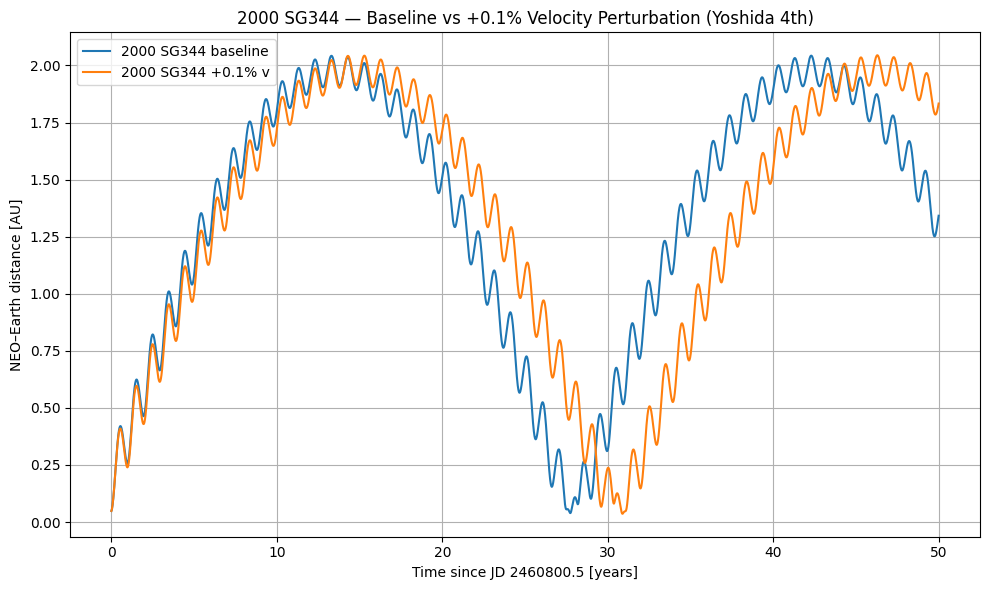


-------------------------MINIMUM DISTANCE REPORT--------------------------
2000 SG344 – Minimum Earth Distance (baseline): 5877656.46 km at year 27.74
2000 SG344 – Minimum Earth Distance (+0.1% v): 5418440.41 km at year 30.89
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 2000SG344_perturbed_0.1_AU.csv
Location : /content/2000SG344_perturbed_0.1_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2000 SG344 - +0.1% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#2000 SG344 orbital parameters
    #@ JD 2460800.5
ecc      = 0.06696           #eccentricity (e)
sm_axis  = 0.97744           #semi-major axis[AU] (a)
inc_deg  = 0.112             #inclination degrees (i) [deg]
asc_node_deg = 191.91        #ascending node degrees (Ω) [deg]
arg_peri_deg  = 275.35       #perhelion (ω) [deg]
mean_anom_epoch_deg = 263.0  #mean anomaly at JD 2460800.5 (M) [deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 2000 SG344 at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.1% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.001   #+0.1% --> 0.001 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.1% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.1% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.001)  #+0.1% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="2000 SG344 baseline")
    plt.plot(t_years_arr, d_pert_AU, label="2000 SG344 +0.1% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("2000 SG344 — Baseline vs +0.1% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("2000 SG344 – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("2000 SG344 – Minimum Earth Distance (+0.1% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")

# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "2000SG344_perturbed_0.1_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

    Code for +0.5%

Code below:

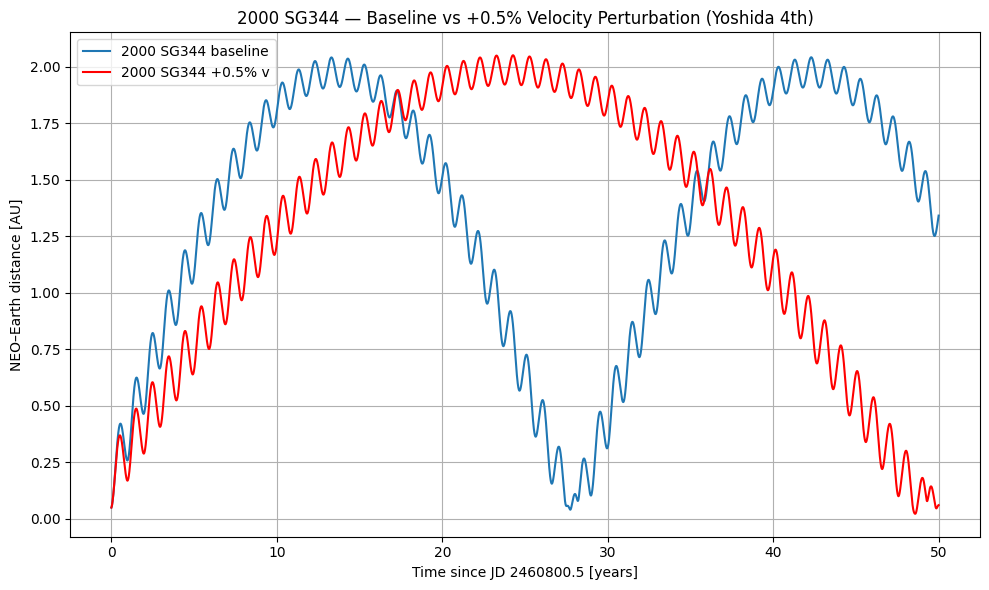


-------------------------MINIMUM DISTANCE REPORT--------------------------
2000 SG344 – Minimum Earth Distance (baseline): 5877656.46 km at year 27.74
2000 SG344 – Minimum Earth Distance (+0.5% v): 3159469.77 km at year 48.58
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 2000SG344_perturbed_0.5_AU.csv
Location : /content/2000SG344_perturbed_0.5_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2000 SG344 - +0.5% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#2000 SG344 orbital parameters
    #@ JD 2460800.5
ecc      = 0.06696           #eccentricity (e)
sm_axis  = 0.97744           #semi-major axis[AU] (a)
inc_deg  = 0.112             #inclination degrees (i) [deg]
asc_node_deg = 191.91        #ascending node degrees (Ω) [deg]
arg_peri_deg  = 275.35       #perhelion (ω) [deg]
mean_anom_epoch_deg = 263.0  #mean anomaly at JD 2460800.5 (M) [deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 2000 SG344 at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.5% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.005   #+0.5% --> 0.005 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.5% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.5% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.005)  #+0.5% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="2000 SG344 baseline")
    plt.plot(t_years_arr, d_pert_AU, color = 'red', label="2000 SG344 +0.5% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("2000 SG344 — Baseline vs +0.5% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("2000 SG344 – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("2000 SG344 – Minimum Earth Distance (+0.5% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")

# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "2000SG344_perturbed_0.5_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

**Simulation 3: Could Become Hazardous**
    
    NEO: 2025 FA22

Parameters: (source - JPL SBDB solution JPL#24) --> same as NRM
- Eccentricity --> **ecc** (e): 0.4149151053
- Semi-major axis --> **sm_axis** (a): 1.5072249272 AU
- Inclination --> **inc** (i): 7.5470805628°
- Longitude of ascending node --> **asc_node** (Ω): 356.5060673229°
- Perihelion --> **p_helion** (ω): 304.9130604139°
- Mean anomaly --> **mean** (M₀): 309.6876512°

New for integrator:
- Grand Epoch (Constant - Earth): 2025-05-05 (JD 2460800.5)
- NEO Epoch (respectively):

Updated Param: Coordinate system
- position --> **r_0** (r_0):
- velocity --> **v_0** (v_0):

Perturbations to NEO (code parameter - +velocity):
- +0.1% velocity
- +0.5% velocity

    Code for +0.1%

Code below:

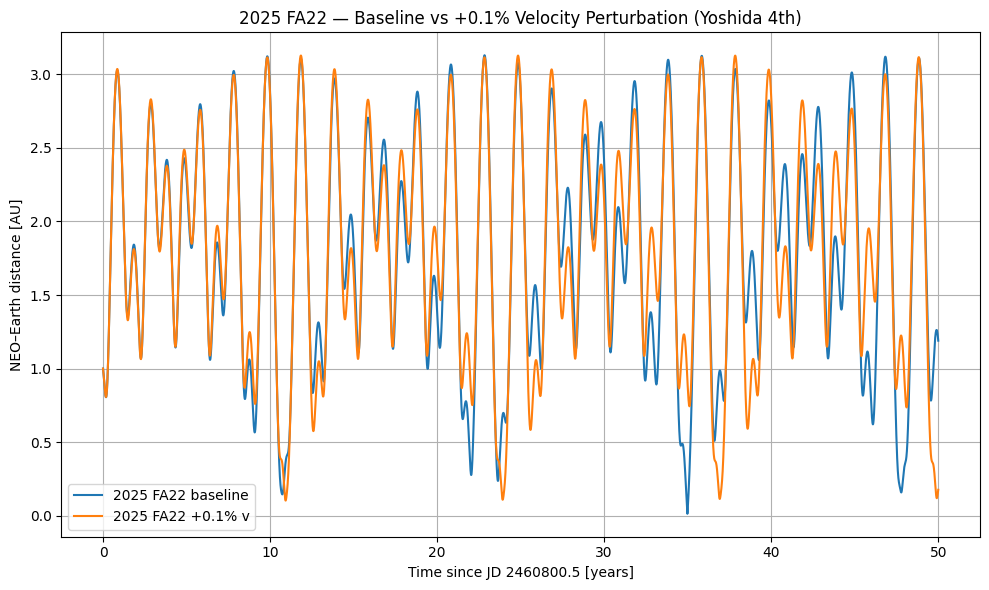


-------------------------MINIMUM DISTANCE REPORT--------------------------
2025 FA22 – Minimum Earth Distance (baseline): 2084778.70 km at year 34.98
2025 FA22– Minimum Earth Distance (+0.1% v): 54642633.89 km at year 10.93
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 2025FA22_perturbed_0.1_AU.csv
Location : /content/2025FA22_perturbed_0.1_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2025 FA22 - +0.1% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#2025 FA22 orbital parameters
    #@ JD 2460800.5
ecc      = 0.4149151053           #eccentricity (e)
sm_axis  = 1.5072249272           #semi-major axis[AU] (a)
inc_deg  = 7.5470805628           #inclination degrees (i) [deg]
asc_node_deg = 356.5060673229     #ascending node degrees (Ω) [deg]
arg_peri_deg  = 304.9130604139    #perhelion (ω) [deg]
mean_anom_epoch_deg = 56.0107712  #mean anomaly at JD 2460800.5 (M) [deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 2025 FA22 at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.1% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.001   #+0.1% --> 0.001 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.1% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.1% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.001)  #+0.1% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="2025 FA22 baseline")
    plt.plot(t_years_arr, d_pert_AU, label="2025 FA22 +0.1% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("2025 FA22 — Baseline vs +0.1% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("2025 FA22 – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("2025 FA22– Minimum Earth Distance (+0.1% v): {:.2f} km at year {:.2f}".format(base_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")

        # ------------------------------------------------------------------
# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "2025FA22_perturbed_0.1_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

    Code for +0.5%

Code below:

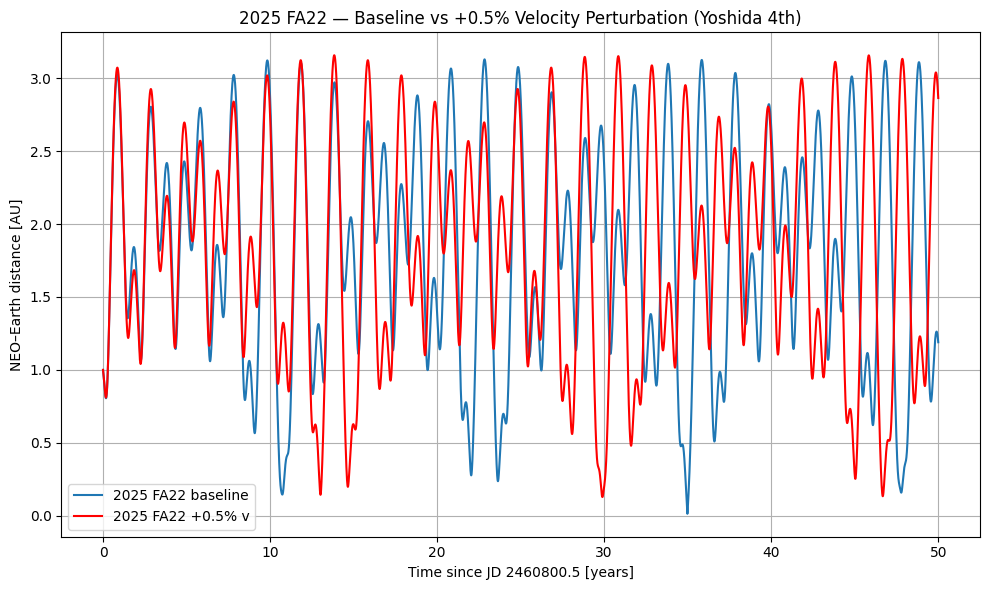


-------------------------MINIMUM DISTANCE REPORT--------------------------
2025 FA22 – Minimum Earth Distance (baseline): 2084778.70 km at year 34.98
2025 FA22– Minimum Earth Distance (+0.5% v): 19248579.96 km at year 29.89
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 2025FA22_perturbed_0.5_AU.csv
Location : /content/2025FA22_perturbed_0.5_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2025 FA22 - +0.5% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#2025 FA22 orbital parameters
    #@ JD 2460800.5
ecc      = 0.4149151053           #eccentricity (e)
sm_axis  = 1.5072249272           #semi-major axis[AU] (a)
inc_deg  = 7.5470805628           #inclination degrees (i) [deg]
asc_node_deg = 356.5060673229     #ascending node degrees (Ω) [deg]
arg_peri_deg  = 304.9130604139    #perhelion (ω) [deg]
mean_anom_epoch_deg = 56.0107712  #mean anomaly at JD 2460800.5 (M) [deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 2025 FA22 at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.5% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.005   #+0.5% --> 0.005 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.5% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.5% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.005)  #+0.5% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="2025 FA22 baseline")
    plt.plot(t_years_arr, d_pert_AU, color = 'red', label="2025 FA22 +0.5% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("2025 FA22 — Baseline vs +0.5% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("2025 FA22 – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("2025 FA22– Minimum Earth Distance (+0.5% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")

# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "2025FA22_perturbed_0.5_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

**Simulation 4: Could Become Hazardous**
    NEO: 101955 Bennu

Parameters: (source - NASA & JPL SBDB) --> Same as NRM
- Eccentricity --> **ecc** (e): 0.2038
- Semi-major axis --> **sm_axis** (a): 1.1264 AU
- Inclination --> **inc** (i): 6.0349°
- Longitude of ascending node --> **asc_node** (Ω): 2.0609°
- Perihelion --> **p_helion** (ω): 66.2231°
- Mean anomaly --> **mean** (M₀): 100.1808437°

New for integrator:
- Grand Epoch (Constant - Earth): 2025-05-05 (JD 2460800.5)
- NEO Epoch (respectively):

Updated Param: Coordinate system
- position --> **r_0** (r_0):
- velocity --> **v_0** (v_0):

Perturbations to NEO (code parameter - +velocity):
- +0.1% velocity
- +0.5% velocity

    Code for +0.1%

Code below:

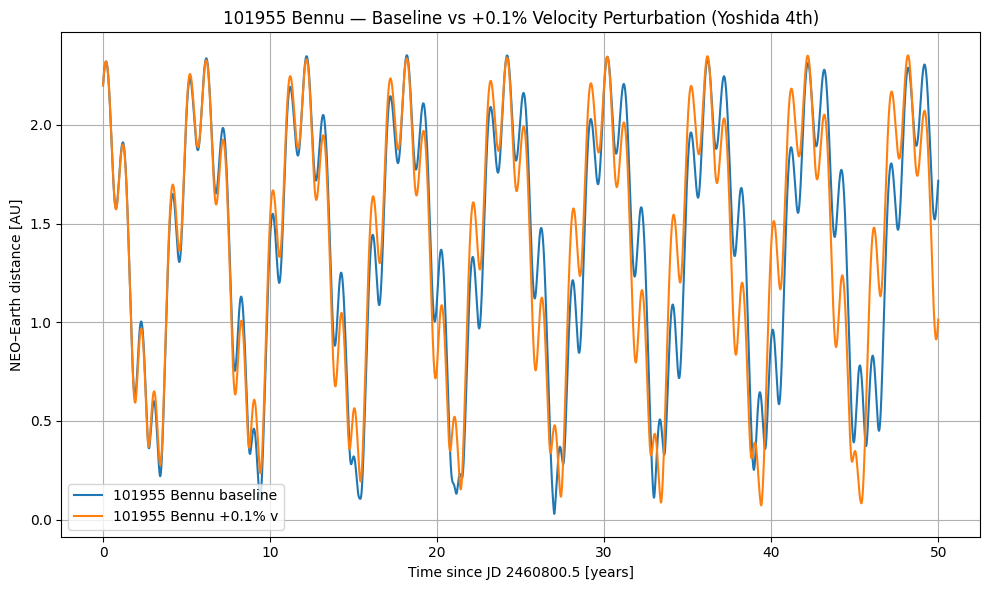


-------------------------MINIMUM DISTANCE REPORT--------------------------
101955 Bennu – Minimum Earth Distance (baseline): 4379866.63 km at year 27.02
101955 Bennu– Minimum Earth Distance (+0.1% v): 10735542.82 km at year 39.40
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 101955Bennu_perturbed_0.1_AU.csv
Location : /content/101955Bennu_perturbed_0.1_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#101955 Bennu - +0.1% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#101955 Bennu orbital parameters
    #@ JD 2460800.5
ecc      = 0.2038           #eccentricity (e)
sm_axis  = 1.1264           #semi-major axis[AU] (a)
inc_deg  = 6.0349           #inclination degrees (i) [deg]
asc_node_deg = 2.0609     #ascending node degrees (Ω) [deg]
arg_peri_deg  = 66.2231    #perhelion (ω) [deg]
mean_anom_epoch_deg = 100.1808437  #mean anomaly at JD 2460800.5 (M) [deg]


#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 101955 Bennu at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.1% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.001   #+0.1% --> 0.001 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.1% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.1% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.001)  #+0.1% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="101955 Bennu baseline")
    plt.plot(t_years_arr, d_pert_AU, label="101955 Bennu +0.1% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("101955 Bennu — Baseline vs +0.1% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("101955 Bennu – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("101955 Bennu– Minimum Earth Distance (+0.1% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")

# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "101955Bennu_perturbed_0.1_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

    Code for +0.5%

Code below:

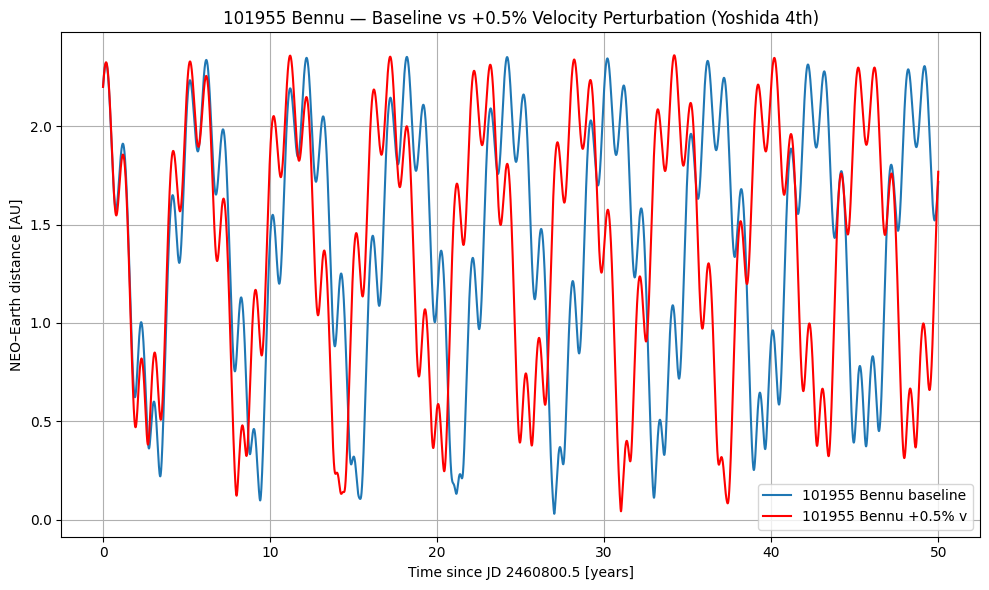


-------------------------MINIMUM DISTANCE REPORT--------------------------
101955 Bennu – Minimum Earth Distance (baseline): 4379866.63 km at year 27.02
101955 Bennu– Minimum Earth Distance (+0.5% v): 6269259.88 km at year 31.01
--------------------------------------------------------------------------

Trajectory successfully exported!
File name: 101955Bennu_perturbed_0.5_AU.csv
Location : /content/101955Bennu_perturbed_0.5_AU.csv
Rows     : 18263


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#101955 Bennu - +0.5% NEO velocity perturbation
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
    #Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]


#101955 Bennu orbital parameters
    #@ JD 2460800.5
ecc      = 0.2038           #eccentricity (e)
sm_axis  = 1.1264           #semi-major axis[AU] (a)
inc_deg  = 6.0349           #inclination degrees (i) [deg]
asc_node_deg = 2.0609     #ascending node degrees (Ω) [deg]
arg_peri_deg  = 66.2231    #perhelion (ω) [deg]
mean_anom_epoch_deg = 100.1808437  #mean anomaly at JD 2460800.5 (M) [deg]


#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
  #for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
  #osculating elements of 101955 Bennu at JD 2460800.5 to J2000 position and velocity (p_0 and v_0)
def elements_to_state():
    e = ecc
    a = sm_axis * AU  #[m]

    i = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0 = d2r(mean_anom_epoch_deg)   #already at the target

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    sin_E = np.sin(E)
    cos_E = np.cos(E)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * cos_E)      #[m]
    p = a * (1.0 - e**2)           #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting) --> New method
  #acceleration from the Sun at position r (gravity based)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1  #symmetric

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    """
    Simple circular orbit for Earth in ecliptic plane.
    t in seconds from epoch.
    """
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> baseline vs +0.5% perturbed NEO
def simulate(
    t_max_years=50.0,
    dt_days=1.0,
    v_pert_frac=0.005   #+0.5% --> 0.005 (converted)
):
    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

       #baseline
    r_baseline = r0.copy()
    v_baseline = v0.copy()

       #+0.5% speed
    r_pert = r0.copy()
    v_pert = (1.0 + v_pert_frac) * v0  #+0.5% speed

    dist_baseline = np.zeros(N)
    dist_pert = np.zeros(N)

    for k, t in enumerate(t_arr):
        r_e = earth_position(t)

        dist_baseline[k] = np.linalg.norm(r_baseline - r_e)
        dist_pert[k] = np.linalg.norm(r_pert     - r_e)

        r_baseline, v_baseline = yoshida4_step(r_baseline, v_baseline, dt)
        r_pert,     v_pert     = yoshida4_step(r_pert,     v_pert,     dt)

    return t_arr, dist_baseline, dist_pert

#run + plot
if __name__ == "__main__":
    t_years = 50.0   #simulate 50 years from epoch
    dt_days = 1.0    #1-day time step

    t, d_base, d_pert = simulate(
        t_max_years=t_years,
        dt_days=dt_days,
        v_pert_frac=0.005)  #+0.5% NEO velocity

    t_years_arr = t / YEAR
    d_base_AU = d_base / AU
    d_pert_AU = d_pert / AU

    plt.figure(figsize=(10, 6))
    plt.plot(t_years_arr, d_base_AU, label="101955 Bennu baseline")
    plt.plot(t_years_arr, d_pert_AU, color = 'red', label="101955 Bennu +0.5% v")

    plt.xlabel("Time since JD 2460800.5 [years]")
    plt.ylabel("NEO–Earth distance [AU]")
    plt.title("101955 Bennu — Baseline vs +0.5% Velocity Perturbation (Yoshida 4th)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#adding extra diagnostics (min Earth distance for baseline + perturbed)
    #convert to km
    base_km = d_base / 1000.0
    pert_km = d_pert / 1000.0

    #find minimum distance (y-axis)
    min_base = np.argmin(base_km)
    min_pert = np.argmin(pert_km)

    #time (years) at min (x-axis)
    min_time_base = t[min_base]/YEAR
    min_time_pert = t[min_pert]/YEAR

    print("\n-------------------------MINIMUM DISTANCE REPORT--------------------------")
    print("101955 Bennu – Minimum Earth Distance (baseline): {:.2f} km at year {:.2f}".format(base_km[min_base], min_time_base))
    print("101955 Bennu– Minimum Earth Distance (+0.5% v): {:.2f} km at year {:.2f}".format(pert_km[min_pert], min_time_pert))
    print("--------------------------------------------------------------------------")

# ======================================================================
# EXPORT PERTURBED TRAJECTORY AS A PROPER CSV
# ======================================================================

import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
import os

# Epoch of the simulation
epoch = datetime(2025, 5, 5)

# Create dates corresponding to each simulation point
dates = [epoch + timedelta(days=i) for i in range(len(d_pert_AU))]

# Create DataFrame
trajectory = pd.DataFrame({
    "Index": range(len(d_pert_AU)),
    "Date": [d.strftime("%Y-%m-%d") for d in dates],
    "Distance_AU": d_pert_AU
})

# Save CSV
filename = "101955Bennu_perturbed_0.5_AU.csv"
trajectory.to_csv(filename, index=False)

# Print confirmation
print("\n====================================================")
print("Trajectory successfully exported!")
print("File name:", filename)
print("Location :", os.path.abspath(filename))
print("Rows     :", len(trajectory))
print("====================================================")

# Automatically download the file
files.download(filename)

### **Conclusive Simulation:**

    Separate one for each NEO
        Bringing them into one figure later

*   y = Minimum Distance to Earth

*   x = Range of velocity


1.   One code that runs same simulation as above for a range of velocities
2.   Plots that minimum distance for each velocity according to the plan (y = minimum distance, x = range of velocity)

**Conclusive Simulation #1**

    NEO: 2024 YR4

Parameters: (source - NASA & JPL SBDB) --> Same as NRM
- Eccentricity --> **ecc** (e): 0.66426900
- Semi-major axis --> **sm_axis** (a): 2.54000858 AU
- Inclination --> **inc** (i): 3.45326192°
- Longitude of ascending node --> **asc_node** (Ω): 271.41230059°
- Perihelion --> **p_helion** (ω): 134.64151115°
- Mean anomaly --> **mean** (M₀): 39.7746°


      The overall relationship is non-linear and seeming to become a quadratic relationship





---------------------MINIMUM DISTANCE SWEEP REPORT----------------------
2024 YR4
velocity_%    min_distance_km    time_of_min_years
   0.0000          8969168.35                43.99
   0.0200          1759070.82                48.27
   0.0400         13160062.27                44.23
   0.0600         11036138.98                35.98
   0.0800          4647153.08                40.26
   0.1000         14350958.21                31.97
   0.1200          5919207.22                36.26
   0.1400         20781727.38                36.30
   0.1600         11295749.56                27.98
   0.1800          4470671.42                32.28
   0.2000         22243539.00                28.11
   0.2200         18087980.12                28.20
   0.2400          2323985.43                28.26
   0.2600         15779158.82                24.04
   0.2800         21974546.11                24.11
   0.3000         19530247.13                24.18
   0.3200          7934747.57                24.25

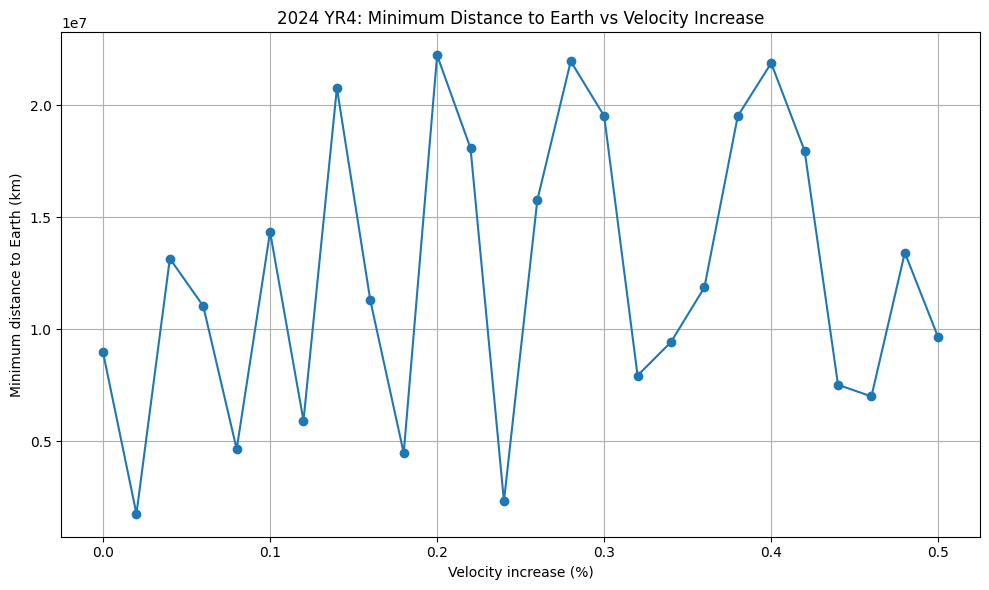

In [ ]:
#2024 YR4 - minimum distance vs velocity increase
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
#Same methods as older simulation
#Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]

#2024 YR4 orbital parameters
#@ JD 2460800.5
ecc                  = 0.66426900
sm_axis              = 2.54000858          #[AU]
inc_deg              = 3.45326192          #[deg]
asc_node_deg         = 271.41230059        #[deg]
arg_peri_deg         = 134.64151115        #[deg]
mean_anom_epoch_deg  = 39.7746             #[deg]

#degrees to radians, helper method
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
#for eccentric anomaly E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state (J2000 heliocentric ecliptic)
def elements_to_state():
    e = ecc
    a = sm_axis * AU   #[m]

    i     = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0    = d2r(mean_anom_epoch_deg)

    #solving E
    E = newtonRaphson(M0, e)

    #true anomaly ν calc
    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    #distance r and semi-latus rectum p
    r = a * (1.0 - e * np.cos(E))   #[m]
    p = a * (1.0 - e**2)            #[m]

    #position and velocity (perifocal)
    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    #rotation matrices
    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1

#Standard velocity-Verlet/leapfrog step of size h
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step (leapfrog)
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit (circular, analytic)
def earth_position(t):
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#simulation --> conclusive sweep over velocity perturbations
def simulate_min_distance_for_velocity_range(
    t_max_years=50.0,
    dt_days=1.0,
    velocity_fractions=None
):
    if velocity_fractions is None:
        velocity_fractions = np.linspace(0.0, 0.005, 26)

    dt  = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    #initial conditions from orbital elements
    r0, v0 = elements_to_state()

    min_distances = np.zeros(len(velocity_fractions))
    min_times_years = np.zeros(len(velocity_fractions))

    for j, frac in enumerate(velocity_fractions):
        r = r0.copy()
        v = (1.0 + frac) * v0.copy()

        dist_arr = np.zeros(N)

        for k, t in enumerate(t_arr):
            r_e = earth_position(t)
            dist_arr[k] = np.linalg.norm(r - r_e)
            r, v = yoshida4_step(r, v, dt)

        min_idx = np.argmin(dist_arr)
        min_distances[j] = dist_arr[min_idx]
        min_times_years[j] = t_arr[min_idx] / YEAR

    return {
        "velocity_fractions": np.array(velocity_fractions),
        "velocity_percent": 100.0 * np.array(velocity_fractions),
        "min_distances_m": min_distances,
        "min_distances_km": min_distances / 1000.0,
        "min_distances_AU": min_distances / AU,
        "time_of_min_years": min_times_years
    }

def print_summary(result):
    print("\n---------------------MINIMUM DISTANCE SWEEP REPORT----------------------")
    print("2024 YR4")
    print("velocity_%    min_distance_km    time_of_min_years")
    for vp, dkm, ty in zip(
        result["velocity_percent"],
        result["min_distances_km"],
        result["time_of_min_years"]
    ):
        print(f"{vp:9.4f}    {dkm:16.2f}    {ty:17.2f}")
    print("------------------------------------------------------------------------")

def plot_min_distance_vs_velocity(result):
    plt.figure(figsize=(10, 6))
    plt.plot(
        result["velocity_percent"],
        result["min_distances_km"],
        marker='o'
    )
    plt.xlabel("Velocity increase (%)")
    plt.ylabel("Minimum distance to Earth (km)")
    plt.title("2024 YR4: Minimum Distance to Earth vs Velocity Increase")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#run + plot
if __name__ == "__main__":
    t_years = 50.0
    dt_days = 1.0

    velocity_fractions = np.linspace(0.0, 0.005, 26)   #0.00% to 0.50%

    result_yr4 = simulate_min_distance_for_velocity_range(
        t_max_years=t_years,
        dt_days=dt_days,
        velocity_fractions=velocity_fractions
    )

    print_summary(result_yr4)
    plot_min_distance_vs_velocity(result_yr4)

**Conclusive Simulation #2**

    NEO: 2000 SG344

Parameters: (source - NASA & JPL SBDB) --> Same as NRM
- Eccentricity --> **ecc** (e): 0.06696
- Semi-major axis --> **sm_axis** (a): 0.97744 AU
- Inclination --> **inc** (i): 0.112°
- Longitude of ascending node --> **asc_node** (Ω): 191.91°
- Perihelion --> **p_helion** (ω): 275.35°
- Mean anomaly --> **mean** (M₀):263.0°


      T





---------------------MINIMUM DISTANCE SWEEP REPORT----------------------
2000 SG344
velocity_%    min_distance_km    time_of_min_years
   0.0000          5877656.46                27.74
   0.0200           569655.70                28.98
   0.0400          5953325.45                28.73
   0.0600          2449107.03                29.97
   0.0800          5165606.01                29.69
   0.1000          5418440.41                30.89
   0.1200          1855309.33                30.61
   0.1400          6782236.08                31.79
   0.1600          3331992.72                32.96
   0.1800          4261198.10                32.65
   0.2000          6936469.90                33.78
   0.2200          5623980.35                34.89
   0.2400           764532.91                34.59
   0.2600          3512679.30                36.99
   0.2800          6861703.24                36.74
   0.3000          7217197.15                37.78
   0.3200          7036173.75                37.

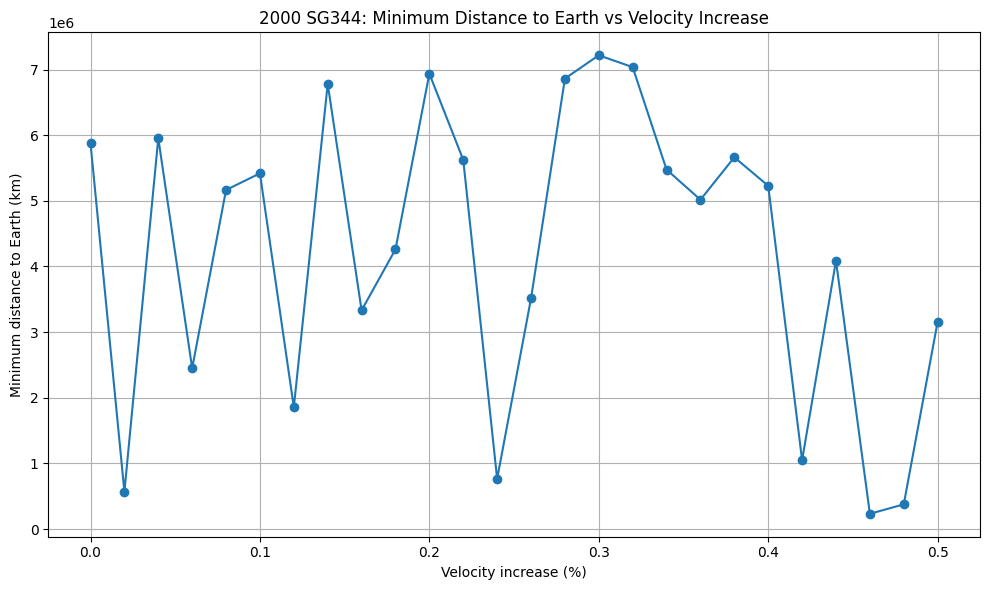

In [ ]:
#2000 SG344 - minimum distance vs velocity increase
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
#Same methods as older simulation
#Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]

#2000 SG344 orbital parameters
#@ JD 2460800.5
ecc                  = 0.06696
sm_axis              = 0.97744          #[AU]
inc_deg              = 0.112            #[deg]
asc_node_deg         = 191.91           #[deg]
arg_peri_deg         = 275.35           #[deg]
mean_anom_epoch_deg  = 263.0            #[deg]

#degrees to radians
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state
def elements_to_state():
    e = ecc
    a = sm_axis * AU

    i     = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0    = d2r(mean_anom_epoch_deg)

    E = newtonRaphson(M0, e)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    r = a * (1.0 - e * np.cos(E))
    p = a * (1.0 - e**2)

    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1

#standard leapfrog
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit
def earth_position(t):
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#core simulation
def simulate_min_distance_for_velocity_range(
    t_max_years=50.0,
    dt_days=1.0,
    velocity_fractions=None
):
    if velocity_fractions is None:
        velocity_fractions = np.linspace(0.0, 0.005, 26)

    dt = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    r0, v0 = elements_to_state()

    min_distances = np.zeros(len(velocity_fractions))
    min_times_years = np.zeros(len(velocity_fractions))

    for j, frac in enumerate(velocity_fractions):
        r = r0.copy()
        v = (1.0 + frac) * v0.copy()

        dist_arr = np.zeros(N)

        for k, t in enumerate(t_arr):
            r_e = earth_position(t)
            dist_arr[k] = np.linalg.norm(r - r_e)
            r, v = yoshida4_step(r, v, dt)

        min_idx = np.argmin(dist_arr)
        min_distances[j] = dist_arr[min_idx]
        min_times_years[j] = t_arr[min_idx] / YEAR

    return {
        "velocity_percent": 100.0 * np.array(velocity_fractions),
        "min_distances_km": min_distances / 1000.0,
        "time_of_min_years": min_times_years
    }

def print_summary(result):
    print("\n---------------------MINIMUM DISTANCE SWEEP REPORT----------------------")
    print("2000 SG344")
    print("velocity_%    min_distance_km    time_of_min_years")
    for vp, dkm, ty in zip(
        result["velocity_percent"],
        result["min_distances_km"],
        result["time_of_min_years"]
    ):
        print(f"{vp:9.4f}    {dkm:16.2f}    {ty:17.2f}")
    print("------------------------------------------------------------------------")

def plot_min_distance_vs_velocity(result):
    plt.figure(figsize=(10, 6))
    plt.plot(
        result["velocity_percent"],
        result["min_distances_km"],
        marker='o'
    )
    plt.xlabel("Velocity increase (%)")
    plt.ylabel("Minimum distance to Earth (km)")
    plt.title("2000 SG344: Minimum Distance to Earth vs Velocity Increase")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#run
if __name__ == "__main__":
    velocity_fractions = np.linspace(0.0, 0.005, 26)

    result_sg344 = simulate_min_distance_for_velocity_range(
        t_max_years=50.0,
        dt_days=1.0,
        velocity_fractions=velocity_fractions
    )

    print_summary(result_sg344)
    plot_min_distance_vs_velocity(result_sg344)

**Conclusive Simulation #3**

    NEO: 2025 FA22

Parameters: (source - NASA & JPL SBDB) --> Same as NRM
- Eccentricity --> ecc (e): 0.4149151053
- Semi-major axis --> sm_axis (a): 1.5072249272 AU
- Inclination --> inc (i): 7.5470805628°
- Longitude of ascending node --> asc_node (Ω): 356.5060673229°
- Perihelion --> p_helion (ω): 304.9130604139°
- Mean anomaly --> mean (M₀): 309.6876512°

      T



---------------------MINIMUM DISTANCE SWEEP REPORT----------------------
2025 FA22
velocity_%    min_distance_km    time_of_min_years
   0.0000          6268734.49                29.97
   0.0200         14428095.07                30.01
   0.0400         10583014.94                43.00
   0.0600         19141042.23                18.69
   0.0800         19168089.39                44.69
   0.1000         21968979.86                44.87
   0.1200          1963997.31                44.99
   0.1400          8267806.54                18.96
   0.1600          4589746.39                18.99
   0.1800         17942601.65                19.01
   0.2000          4372034.08                46.99
   0.2200         12462602.71                 5.94
   0.2400          3500311.14                33.99
   0.2600          5299622.46                 5.97
   0.2800          1685802.85                 5.98
   0.3000          2957343.78                 5.99
   0.3200          5006758.81                20.9

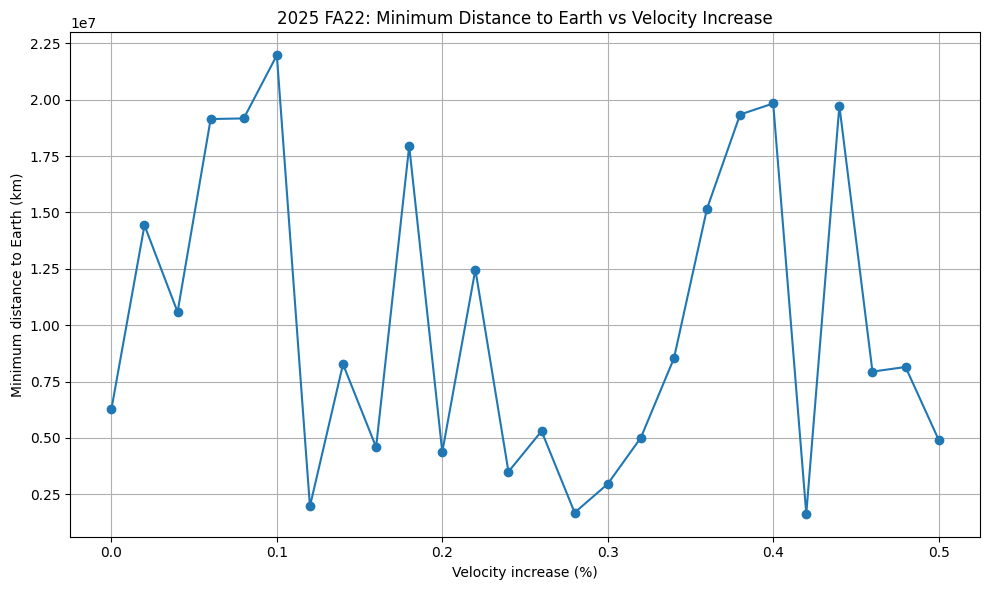

In [ ]:
#2025 FA22 - minimum distance vs velocity increase
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
#Same methods as older simulation
#Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]

#2025 FA22 orbital parameters
#@ JD 2460800.5
ecc                  = 0.4149151053
sm_axis              = 1.5072249272       #[AU]
inc_deg              = 7.5470805628       #[deg]
asc_node_deg         = 356.5060673229     #[deg]
arg_peri_deg         = 304.9130604139     #[deg]
mean_anom_epoch_deg  = 309.6876512        #[deg]

#degrees to radians
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state
def elements_to_state():
    e = ecc
    a = sm_axis * AU

    i     = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0    = d2r(mean_anom_epoch_deg)

    E = newtonRaphson(M0, e)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    r = a * (1.0 - e * np.cos(E))
    p = a * (1.0 - e**2)

    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1

#standard leapfrog
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit
def earth_position(t):
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#core simulation
def simulate_min_distance_for_velocity_range(
    t_max_years=50.0,
    dt_days=1.0,
    velocity_fractions=None
):
    if velocity_fractions is None:
        velocity_fractions = np.linspace(0.0, 0.005, 26)

    dt = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    r0, v0 = elements_to_state()

    min_distances = np.zeros(len(velocity_fractions))
    min_times_years = np.zeros(len(velocity_fractions))

    for j, frac in enumerate(velocity_fractions):
        r = r0.copy()
        v = (1.0 + frac) * v0.copy()

        dist_arr = np.zeros(N)

        for k, t in enumerate(t_arr):
            r_e = earth_position(t)
            dist_arr[k] = np.linalg.norm(r - r_e)
            r, v = yoshida4_step(r, v, dt)

        min_idx = np.argmin(dist_arr)
        min_distances[j] = dist_arr[min_idx]
        min_times_years[j] = t_arr[min_idx] / YEAR

    return {
        "velocity_percent": 100.0 * np.array(velocity_fractions),
        "min_distances_km": min_distances / 1000.0,
        "time_of_min_years": min_times_years
    }

def print_summary(result):
    print("\n---------------------MINIMUM DISTANCE SWEEP REPORT----------------------")
    print("2025 FA22")
    print("velocity_%    min_distance_km    time_of_min_years")
    for vp, dkm, ty in zip(
        result["velocity_percent"],
        result["min_distances_km"],
        result["time_of_min_years"]
    ):
        print(f"{vp:9.4f}    {dkm:16.2f}    {ty:17.2f}")
    print("------------------------------------------------------------------------")

def plot_min_distance_vs_velocity(result):
    plt.figure(figsize=(10, 6))
    plt.plot(
        result["velocity_percent"],
        result["min_distances_km"],
        marker='o'
    )
    plt.xlabel("Velocity increase (%)")
    plt.ylabel("Minimum distance to Earth (km)")
    plt.title("2025 FA22: Minimum Distance to Earth vs Velocity Increase")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#run
if __name__ == "__main__":
    velocity_fractions = np.linspace(0.0, 0.005, 26)

    result_fa22 = simulate_min_distance_for_velocity_range(
        t_max_years=50.0,
        dt_days=1.0,
        velocity_fractions=velocity_fractions
    )

    print_summary(result_fa22)
    plot_min_distance_vs_velocity(result_fa22)

**Conclusive Simulation #4**

    NEO: 101955 Bennu

Parameters: (source - NASA & JPL SBDB) --> Same as NRM
- Eccentricity --> **ecc** (e): 0.2038
- Semi-major axis --> **sm_axis** (a): 1.1264 AU
- Inclination --> **inc** (i): 6.0349°
- Longitude of ascending node --> **asc_node** (Ω): 2.0609°
- Perihelion --> **p_helion** (ω): 66.2231°
- Mean anomaly --> **mean** (M₀): 100.1808437°


      T


---------------------MINIMUM DISTANCE SWEEP REPORT----------------------
101955 Bennu
velocity_%    min_distance_km    time_of_min_years
   0.0000          4379866.63                27.02
   0.0200           639950.97                33.00
   0.0400           293651.93                39.01
   0.0600          6696495.17                45.02
   0.0800         10716713.65                27.40
   0.1000         10735542.82                39.40
   0.1200         19556903.18                45.41
   0.1400         40130781.58                45.43
   0.1600         46431494.53                 3.43
   0.1800         44573563.10                49.96
   0.2000         20193131.32                49.98
   0.2200          5441170.92                50.00
   0.2400           934719.19                38.01
   0.2600          2495052.50                32.02
   0.2800          1846846.14                26.01
   0.3000         10650623.88                26.05
   0.3200          2106160.88                2

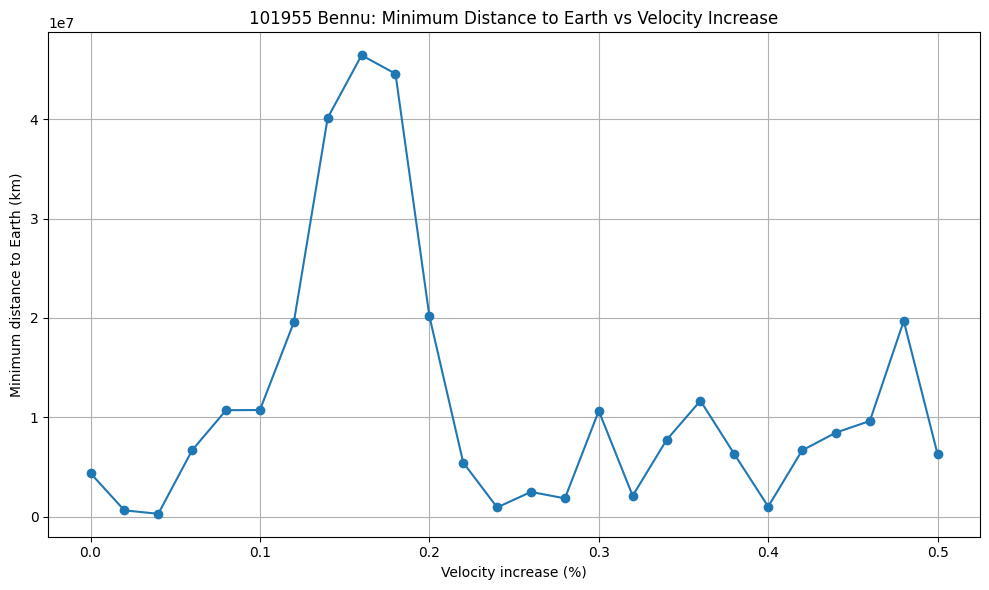

In [ ]:
#101955 Bennu - minimum distance vs velocity increase
#Newton–Raphson (for Kepler E) + Yoshida 4th / WH-style symplectic
#Same methods as older simulation
#Epoch of state vector: JD 2460800.5 (2025-05-05), J2000, heliocentric ecliptic

#imports
import numpy as np
import matplotlib.pyplot as plt

#constants
AU   = 1.495978707e11        #[m] Astronomical Unit
DAY  = 86400.0               #[s]
YEAR = 365.25 * DAY          #[s]

#Sun constants
mu_sun   = 1.32712440018e20  #[m^3/s^2] GM☉

#Earth (constant --> not entirely accurate)
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)
n_earth      = v_earth_mean / r_earth_mean   #[rad/s]

#101955 Bennu orbital parameters
#@ JD 2460800.5
ecc                  = 0.2038            #[ ]
sm_axis              = 1.1264            #[AU]
inc_deg              = 6.0349            #[deg]
asc_node_deg         = 2.0609            #[deg]
arg_peri_deg         = 66.2231           #[deg]
mean_anom_epoch_deg  = 100.1808437       #[deg]

#degrees to radians
def d2r(deg):
    return np.deg2rad(deg)

#Kepler --> M = E - e sin E
def newtonRaphson(M, e, tol=1e-14, max_iter=50):
    if e < 0.8:
        E = M
    else:
        E = np.pi

    for _ in range(max_iter):
        f  = E - e * np.sin(E) - M
        fp = 1.0 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break

    return E

#convert elements --> Cartesian state
def elements_to_state():
    e = ecc
    a = sm_axis * AU

    i     = d2r(inc_deg)
    Omega = d2r(asc_node_deg)
    omega = d2r(arg_peri_deg)
    M0    = d2r(mean_anom_epoch_deg)

    E = newtonRaphson(M0, e)

    nu = 2.0 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2.0),
        np.sqrt(1 - e) * np.cos(E / 2.0)
    )

    r = a * (1.0 - e * np.cos(E))
    p = a * (1.0 - e**2)

    r_pf = np.array([
        r * np.cos(nu),
        r * np.sin(nu),
        0.0
    ])

    factor = np.sqrt(mu_sun / p)
    v_pf = factor * np.array([
        -np.sin(nu),
        e + np.cos(nu),
        0.0
    ])

    def R3(theta):
        return np.array([
            [ np.cos(theta), -np.sin(theta), 0.0],
            [ np.sin(theta),  np.cos(theta), 0.0],
            [ 0.0,            0.0,           1.0]
        ])

    def R1(theta):
        return np.array([
            [1.0, 0.0,           0.0],
            [0.0, np.cos(theta), -np.sin(theta)],
            [0.0, np.sin(theta),  np.cos(theta)]
        ])

    Q = R3(Omega) @ R1(i) @ R3(omega)

    r_ijk = Q @ r_pf
    v_ijk = Q @ v_pf

    return r_ijk, v_ijk

#------------------------------------------------------------------------------------
#symplectic integrator implement: Yoshida 4th (WH-style T+V splitting)
def accel_sun(r):
    r_norm = np.linalg.norm(r)
    return -mu_sun * r / (r_norm**3)

#Yoshida 4th coefficients
c1 = 1.0 / (2.0 - 2.0**(1.0/3.0))
c2 = -2.0**(1.0/3.0) / (2.0 - 2.0**(1.0/3.0))
c3 = c1

#standard leapfrog
def leapfrog_step(r, v, h):
    a = accel_sun(r)
    v_half = v + 0.5 * h * a
    r_new = r + h * v_half
    a_new = accel_sun(r_new)
    v_new = v_half + 0.5 * h * a_new
    return r_new, v_new

#Yoshida 4th-order symplectic step
def yoshida4_step(r, v, h):
    r, v = leapfrog_step(r, v, c1 * h)
    r, v = leapfrog_step(r, v, c2 * h)
    r, v = leapfrog_step(r, v, c3 * h)
    return r, v
#------------------------------------------------------------------------------------

#Earth reference orbit
def earth_position(t):
    theta = n_earth * t
    return np.array([
        r_earth_mean * np.cos(theta),
        r_earth_mean * np.sin(theta),
        0.0
    ])

#core simulation
def simulate_min_distance_for_velocity_range(
    t_max_years=50.0,
    dt_days=1.0,
    velocity_fractions=None
):
    if velocity_fractions is None:
        velocity_fractions = np.linspace(0.0, 0.005, 26)

    dt = dt_days * DAY
    t_max = t_max_years * YEAR
    N = int(np.round(t_max / dt)) + 1
    t_arr = np.linspace(0.0, t_max, N)

    r0, v0 = elements_to_state()

    min_distances = np.zeros(len(velocity_fractions))
    min_times_years = np.zeros(len(velocity_fractions))

    for j, frac in enumerate(velocity_fractions):
        r = r0.copy()
        v = (1.0 + frac) * v0.copy()

        dist_arr = np.zeros(N)

        for k, t in enumerate(t_arr):
            r_e = earth_position(t)
            dist_arr[k] = np.linalg.norm(r - r_e)
            r, v = yoshida4_step(r, v, dt)

        min_idx = np.argmin(dist_arr)
        min_distances[j] = dist_arr[min_idx]
        min_times_years[j] = t_arr[min_idx] / YEAR

    return {
        "velocity_percent": 100.0 * np.array(velocity_fractions),
        "min_distances_km": min_distances / 1000.0,
        "time_of_min_years": min_times_years
    }

def print_summary(result):
    print("\n---------------------MINIMUM DISTANCE SWEEP REPORT----------------------")
    print("101955 Bennu")
    print("velocity_%    min_distance_km    time_of_min_years")
    for vp, dkm, ty in zip(
        result["velocity_percent"],
        result["min_distances_km"],
        result["time_of_min_years"]
    ):
        print(f"{vp:9.4f}    {dkm:16.2f}    {ty:17.2f}")
    print("------------------------------------------------------------------------")

def plot_min_distance_vs_velocity(result):
    plt.figure(figsize=(10, 6))
    plt.plot(
        result["velocity_percent"],
        result["min_distances_km"],
        marker='o'
    )
    plt.xlabel("Velocity increase (%)")
    plt.ylabel("Minimum distance to Earth (km)")
    plt.title("101955 Bennu: Minimum Distance to Earth vs Velocity Increase")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#run
if __name__ == "__main__":
    velocity_fractions = np.linspace(0.0, 0.005, 26)

    result_bennu = simulate_min_distance_for_velocity_range(
        t_max_years=50.0,
        dt_days=1.0,
        velocity_fractions=velocity_fractions
    )

    print_summary(result_bennu)
    plot_min_distance_vs_velocity(result_bennu)